In [16]:
# к решению задачи о
# движении парусного судна
# в направлении, противоположном
# направлению ветра

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение библиотеки цветовых схем для 3D графиков
from matplotlib import cm


In [ ]:
# Ячейка № 2
# задание функции, возвращающей
# "истинное" значения угла
# между вектором а и
# положительным направлением
# оси абсцисс, отсчитываемым
# против часовой стрелки
def AngleTrue(a):
    # задание единичного вектора,
    # сонаправленного с осью абсцисс
    ex = np.array([1, 0])

    # вычисление "истинного" значения угла
    if (a[0] >= 0) and (a[1] >= 0):
        z = np.arccos(np.dot(a, ex) / np.linalg.norm(a))
    if (a[0] <= 0) and (a[1] >= 0):
        z = np.arccos(np.dot(a, ex) / np.linalg.norm(a))
    if (a[0] <= 0) and (a[1] <= 0):
        z = 2 * np.pi - np.arccos(np.dot(a, ex) / np.linalg.norm(a))
    if (a[0] >= 0) and (a[1] < 0):
        z = 2 * np.pi - np.arccos(np.dot(a, ex) / np.linalg.norm(a))
    return z

In [ ]:
# Ячейка № 3

# задание функции, возвращающей
# истинное значение проекции
# вектора b на вектор a
def VectorProjection(b, a):
    # вычисление истинного значения угла между
    # вектором b и положительным направлением
    # оси абсцисс
    AngleB = AngleTrue(b)

    # вычисление истинного значения угла между
    # вектором a и положительным направлением
    # оси абсцисс
    AngleA = AngleTrue(a)

    # вычисление длины проекции вектора b на вектор a
    L = np.linalg.norm(b) * np.cos(AngleB - AngleA)

    # вычисление координат проекции вектора b на вектор a
    z = np.array([L * np.cos(AngleA), L * np.sin(AngleA)])

    return z

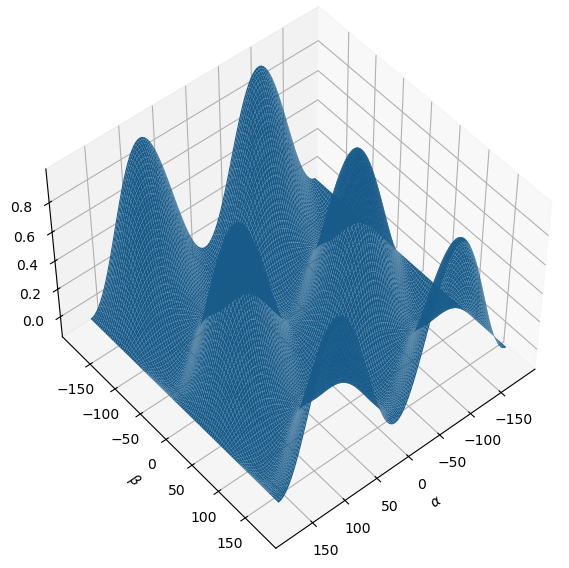

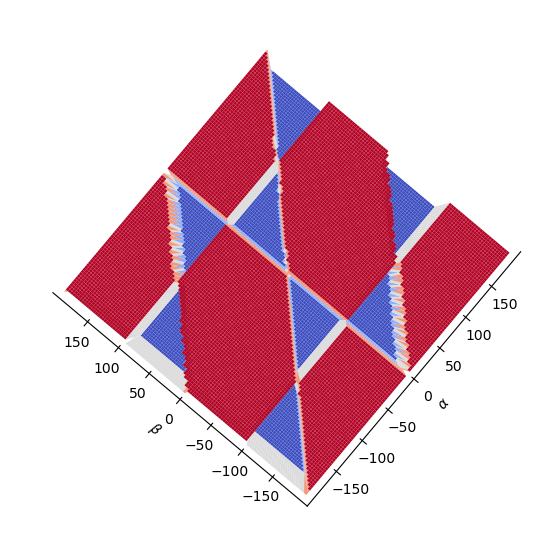

In [ ]:
# Ячейка № 4

# задание вектора скорости ветра
Vw = np.array([0, 1])

# задание числа узлов координатных сеток
# по переменным Alpha и Beta, соответственно
Np = 111

# инициализация массива, используемого для хранения
# координат узлов по переменным Alpha и Beta, соответственно
Alpha = np.zeros(Np)
Beta = np.zeros(Np)

# вычисление координат
# узлов по переменным Alpha и Beta
for i in range(Np):
    Alpha[i] = np.pi - 2 * np.pi / (Np - 1) * i
    Beta[i] = np.pi - 2 * np.pi / (Np - 1) * i
# инициализация массива размерностью Np x Np.
# используемого для хранения значений проекции
# составляющей скорости движения
# парусного судна на направление ветра
# для заданных значений углов
S = np.zeros((Np, Np))

# вычисление значений проекции
# составляющей скорости движения
# парусного судна на направление ветра
# для заданных значений углов
for j in range(Np):
    Vp = np.array([np.cos(Beta[j]), np.sin(Beta[j])])
    for i in range(Np):
        Vs = np.array([np.cos(Alpha[i]), np.sin(Alpha[i])])
        Vw2Vs = VectorProjection(Vw, Vs)
        Vw2Vs_pend = Vw - Vw2Vs
        Vw2Vs_pend2Vp = VectorProjection(Vw2Vs_pend, Vp)
        S[i, j] = np.dot(Vw, Vw2Vs_pend2Vp)

# визуализация поверхности,
# задаваемой матрицей S

# создание матриц A, B, содержащих
# координаты узлов сетки, используемой для
# для 3D визуализации
A, B = np.meshgrid(Alpha * 180 / np.pi, Beta * 180 / np.pi)

# визуализация поверхности, задаваемой матрицей S (рис. 1.19)

fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection="3d")
ax.plot_surface(A, B, S, rstride=1, cstride=1)
ax.view_init(50, 50)
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\beta$")
plt.show()

# визуализация поверхности, задаваемой знаками
# элементов матрицы S

fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection="3d")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$\beta$")
ax.plot_surface(A, B, np.sign(S), cmap=cm.coolwarm, rstride=1, cstride=1)
ax.view_init(elev=90, azim=90, roll=230)
ax.set_zticks([])
ax.zaxis.line.set_lw(0.0)
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
fig.set_facecolor("white")
ax.set_facecolor("white")
ax.xaxis.pane.set_edgecolor("w")
ax.yaxis.pane.set_edgecolor("w")
ax.zaxis.pane.set_edgecolor("w")
plt.show()